In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
def time_axis(fs, duration):
    return np.arange(0, duration, 1/fs)
def generate_sine(f, t, a = 1, p = 0):
    return a*np.sin(2*np.pi*f*t + p)
def spectrum(x, fs, NFFT = -1):
    N = len(x)
    if NFFT == -1:
        NFFT = N
    X = np.fft.fft(x, NFFT)
    X = X[:NFFT//2]
    mag = np.abs(X)*2/N
    freq= np.arange(len(mag)) * fs/NFFT
    return freq, mag

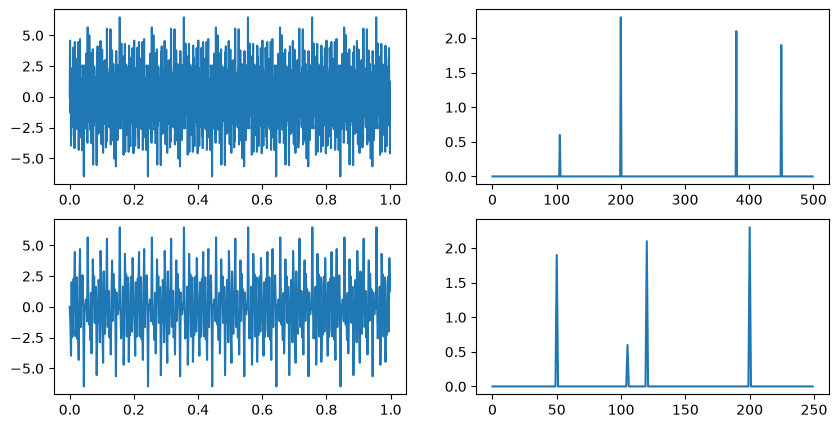

In [5]:
fs = 1000
duration = 1
t = time_axis(fs, duration)
x = generate_sine(105, t, 0.6) + generate_sine(450, t, 1.9) + generate_sine(200, t, 2.3) + generate_sine(380, t, 2.1)
plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1); plt.plot(t, x)
freq, mag = spectrum(x, fs)
plt.subplot(2, 2, 2); plt.plot(freq, mag)

f_new = 500
M = int(fs/f_new)
x_new = x[::M]
t_new = t[::M]
plt.subplot(2, 2, 3); plt.plot(t_new, x_new)
freq, mag = spectrum(x_new, f_new)
plt.subplot(2, 2, 4); plt.plot(freq, mag)

when we do the downsampling, create aliasing

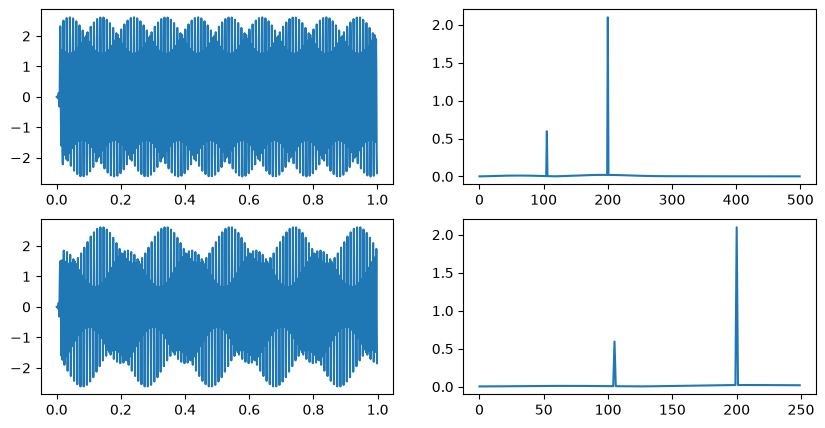

In [6]:
# filter the freq that make aliasing out
b = signal.firwin(numtaps = 21, cutoff = 250, fs = fs, pass_zero = "lowpass")
a = [1.0]
x_low = signal.lfilter(b, a, x)
plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1); plt.plot(t, x_low)
freq, mag = spectrum(x_low, fs)
plt.subplot(2, 2, 2); plt.plot(freq, mag)

f_new = 500
M = int(fs/f_new)
x_new = x_low[::M]
t_new = t[::M]
plt.subplot(2, 2, 3); plt.plot(t_new, x_new)
freq, mag = spectrum(x_new, f_new)
plt.subplot(2, 2, 4); plt.plot(freq, mag)

Beside using the actual filter then do the downsampling, we can use decimate function which will perform both

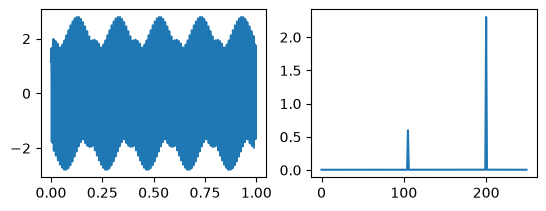

In [9]:
f_new = 500
M = int(fs/f_new)

x_new = signal.decimate(x, M, ftype = 'fir', zero_phase = True)
t_new = np.arange(len(x_new)) / f_new
plt.subplot(2, 2, 3); plt.plot(t_new, x_new)
freq, mag = spectrum(x_new, f_new)
plt.subplot(2, 2, 4); plt.plot(freq, mag)

resample_poly can be use for both down and up sampling - according to the value a and b which calculated: fs_new = a/b * fs

500.0


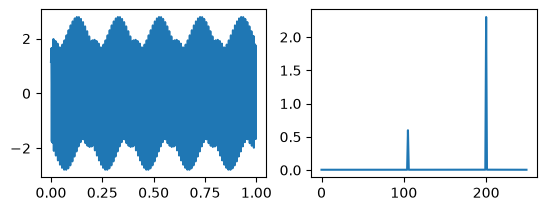

In [12]:
a = 1 #up
b = 2 #down
f_new = a/b * fs
print(f_new)

x_new = signal.resample_poly(x, a, b)
t_new = np.arange(len(x_new)) / f_new
plt.subplot(2, 2, 3); plt.plot(t_new, x_new)
freq, mag = spectrum(x_new, f_new)
plt.subplot(2, 2, 4); plt.plot(freq, mag)

Upsampling

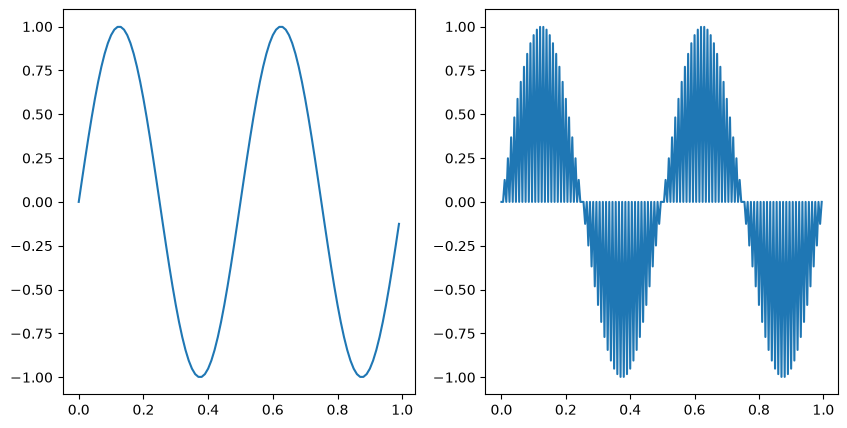

In [16]:
fs = 100
duration = 1
t = time_axis(fs, duration)

x = generate_sine(2, t, 1)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(t, x)

fs_new = 200
L = int(fs_new / fs)
x_up = np.zeros(len(x)*L)
x_up[::L] = x
t_up = np.arange(len(x_up)) / fs_new
plt.subplot(1, 2, 2)
plt.plot(t_up, x_up)